<a href="https://colab.research.google.com/github/lynchpo/DSE5002_Module2/blob/main/Capstone_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import TimeSeriesSplit
import requests
from io import StringIO

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', '{:.3f}'.format)

In [2]:
series_urls = {
    'MORTGAGE30US': 'https://fred.stlouisfed.org/graph/fredgraph.csv?id=MORTGAGE30US',
    'DGS10':        'https://fred.stlouisfed.org/graph/fredgraph.csv?id=DGS10',
    'FEDFUNDS':     'https://fred.stlouisfed.org/graph/fredgraph.csv?id=FEDFUNDS',
    'UNRATE':       'https://fred.stlouisfed.org/graph/fredgraph.csv?id=UNRATE',
    'CPIAUCSL':     'https://fred.stlouisfed.org/graph/fredgraph.csv?id=CPIAUCSL',
    'HOUST':        'https://fred.stlouisfed.org/graph/fredgraph.csv?id=HOUST'
}

raw = {}
for name, url in series_urls.items():
    r = requests.get(url, timeout=20)
    r.raise_for_status()
    df = pd.read_csv(StringIO(r.text), parse_dates=['observation_date'])
    df = df.rename(columns={'observation_date': 'date', name: name})
    df = df.set_index('date').sort_index()
    raw[name] = df
    print(f"{name:12} | {len(df):5} rows | {df.index.min().date()} → {df.index.max().date()}")

MORTGAGE30US |  2888 rows | 1971-04-02 → 2026-07-30
DGS10        | 16848 rows | 1962-01-02 → 2026-07-30
FEDFUNDS     |   864 rows | 1954-07-01 → 2026-06-01
UNRATE       |   942 rows | 1948-01-01 → 2026-06-01
CPIAUCSL     |   954 rows | 1947-01-01 → 2026-06-01
HOUST        |   810 rows | 1959-01-01 → 2026-06-01


In [3]:
# Restrict to 2000 onward and resample everything to weekly frequency
start = '2000-01-01'

# Weekly series (already weekly)
mort = raw['MORTGAGE30US'].loc[start:].resample('W-FRI').last()

# Daily → weekly
dgs10 = raw['DGS10'].loc[start:].resample('W-FRI').last()

# Monthly → weekly (forward-fill after resampling)
fed   = raw['FEDFUNDS'].loc[start:].resample('W-FRI').last().ffill()
unrate= raw['UNRATE'].loc[start:].resample('W-FRI').last().ffill()
cpi   = raw['CPIAUCSL'].loc[start:].resample('W-FRI').last().ffill()
houst = raw['HOUST'].loc[start:].resample('W-FRI').last().ffill()

# Combine
df = pd.concat([mort, dgs10, fed, unrate, cpi, houst], axis=1)
df.columns = ['MORTGAGE30US', 'DGS10', 'FEDFUNDS', 'UNRATE', 'CPIAUCSL', 'HOUST']

print("Shape after alignment:", df.shape)
print("\nMissing values after alignment + forward-fill:")
print(df.isna().sum())

Shape after alignment: (1387, 6)

Missing values after alignment + forward-fill:
MORTGAGE30US    0
DGS10           0
FEDFUNDS        8
UNRATE          8
CPIAUCSL        8
HOUST           8
dtype: int64


In [4]:
# Create working copy
feat = df.copy()

# 1. Yield-curve spread
feat['YIELD_SPREAD'] = feat['DGS10'] - feat['FEDFUNDS']

# 2. Lags of target and key predictors (1, 2, 4 weeks)
lag_vars = ['MORTGAGE30US', 'DGS10', 'FEDFUNDS', 'YIELD_SPREAD']
for var in lag_vars:
    for lag in [1, 2, 4]:
        feat[f'{var}_lag{lag}'] = feat[var].shift(lag)

# 3. Rolling statistics (4-week and 12-week)
for var in ['MORTGAGE30US', 'DGS10', 'FEDFUNDS']:
    feat[f'{var}_roll4_mean'] = feat[var].rolling(4).mean()
    feat[f'{var}_roll4_std']  = feat[var].rolling(4).std()
    feat[f'{var}_roll12_mean']= feat[var].rolling(12).mean()

# Drop rows that became NaN because of lag/rolling creation
feat = feat.dropna()

print("Shape after feature engineering:", feat.shape)
print("\nFeature columns:")
print(feat.columns.tolist())

Shape after feature engineering: (1368, 28)

Feature columns:
['MORTGAGE30US', 'DGS10', 'FEDFUNDS', 'UNRATE', 'CPIAUCSL', 'HOUST', 'YIELD_SPREAD', 'MORTGAGE30US_lag1', 'MORTGAGE30US_lag2', 'MORTGAGE30US_lag4', 'DGS10_lag1', 'DGS10_lag2', 'DGS10_lag4', 'FEDFUNDS_lag1', 'FEDFUNDS_lag2', 'FEDFUNDS_lag4', 'YIELD_SPREAD_lag1', 'YIELD_SPREAD_lag2', 'YIELD_SPREAD_lag4', 'MORTGAGE30US_roll4_mean', 'MORTGAGE30US_roll4_std', 'MORTGAGE30US_roll12_mean', 'DGS10_roll4_mean', 'DGS10_roll4_std', 'DGS10_roll12_mean', 'FEDFUNDS_roll4_mean', 'FEDFUNDS_roll4_std', 'FEDFUNDS_roll12_mean']


In [5]:
# Use last 20% of time as test set (time-ordered, no shuffling)
split_idx = int(len(feat) * 0.80)
train = feat.iloc[:split_idx]
test  = feat.iloc[split_idx:]

print(f"Train period: {train.index.min().date()} → {train.index.max().date()}  ({len(train)} rows)")
print(f"Test  period: {test.index.min().date()} → {test.index.max().date()}  ({len(test)} rows)")

# Quick check that the split does not create weird distribution shifts in the target
print("\nTarget mean – Train:", round(train['MORTGAGE30US'].mean(), 3))
print("Target mean – Test :", round(test['MORTGAGE30US'].mean(), 3))

Train period: 2000-03-24 → 2021-03-05  (1094 rows)
Test  period: 2021-03-12 → 2026-06-05  (274 rows)

Target mean – Train: 5.04
Target mean – Test : 5.827


In [6]:
print("Missing values in TRAIN:")
print(train.isna().sum().sum())
print("\nMissing values in TEST:")
print(test.isna().sum().sum())

Missing values in TRAIN:
0

Missing values in TEST:
0


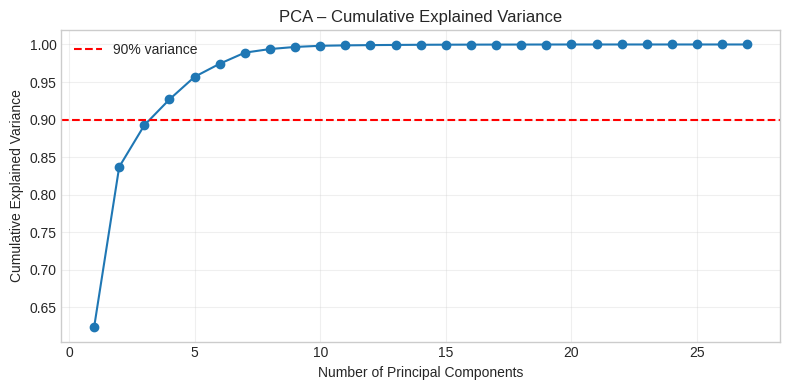

Components needed for 90% variance: 4
Components needed for 95% variance: 5


In [7]:
# Simple PCA on the engineered features (excluding the target)
feature_cols = [c for c in train.columns if c != 'MORTGAGE30US']
X_train = train[feature_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

pca = PCA()
pca.fit(X_scaled)

# Cumulative explained variance
cum_var = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o')
plt.axhline(0.90, color='red', linestyle='--', label='90% variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA – Cumulative Explained Variance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Components needed for 90% variance:", np.argmax(cum_var >= 0.90) + 1)
print("Components needed for 95% variance:", np.argmax(cum_var >= 0.95) + 1)

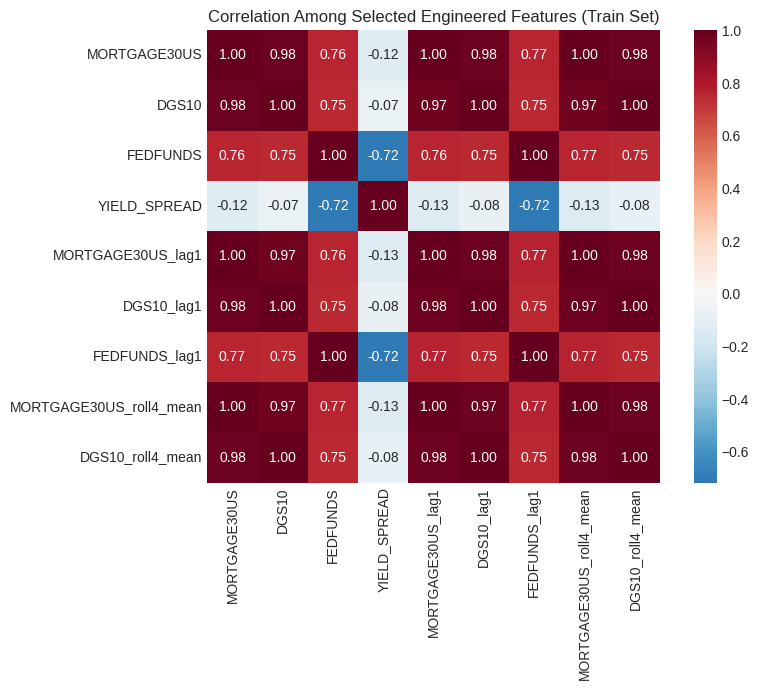

In [8]:
# Quick look at correlation among a subset of engineered features
selected = ['MORTGAGE30US', 'DGS10', 'FEDFUNDS', 'YIELD_SPREAD',
            'MORTGAGE30US_lag1', 'DGS10_lag1', 'FEDFUNDS_lag1',
            'MORTGAGE30US_roll4_mean', 'DGS10_roll4_mean']

corr_eng = train[selected].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_eng, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True)
plt.title("Correlation Among Selected Engineered Features (Train Set)")
plt.tight_layout()
plt.show()

In [9]:
print("=== PREPROCESSING SUMMARY ===")
print(f"Original series aligned to weekly frequency: {df.shape}")
print(f"After lag/rolling feature creation + dropna: {feat.shape}")
print(f"Train size: {len(train)} | Test size: {len(test)}")
print(f"Number of engineered features (excl. target): {len(feature_cols)}")
print("\nFeature list:")
for c in feature_cols:
    print(" -", c)

=== PREPROCESSING SUMMARY ===
Original series aligned to weekly frequency: (1387, 6)
After lag/rolling feature creation + dropna: (1368, 28)
Train size: 1094 | Test size: 274
Number of engineered features (excl. target): 27

Feature list:
 - DGS10
 - FEDFUNDS
 - UNRATE
 - CPIAUCSL
 - HOUST
 - YIELD_SPREAD
 - MORTGAGE30US_lag1
 - MORTGAGE30US_lag2
 - MORTGAGE30US_lag4
 - DGS10_lag1
 - DGS10_lag2
 - DGS10_lag4
 - FEDFUNDS_lag1
 - FEDFUNDS_lag2
 - FEDFUNDS_lag4
 - YIELD_SPREAD_lag1
 - YIELD_SPREAD_lag2
 - YIELD_SPREAD_lag4
 - MORTGAGE30US_roll4_mean
 - MORTGAGE30US_roll4_std
 - MORTGAGE30US_roll12_mean
 - DGS10_roll4_mean
 - DGS10_roll4_std
 - DGS10_roll12_mean
 - FEDFUNDS_roll4_mean
 - FEDFUNDS_roll4_std
 - FEDFUNDS_roll12_mean
